# Phase 6 -- Experiments and Robustness Analysis

## Objective

Validate and stress-test the SVD-based cancer classification pipeline through systematic experiments. This notebook addresses three key questions:

1. **How many SVD components are needed?** -- Rank sensitivity analysis
2. **Does preprocessing matter?** -- Normalization method comparison
3. **Which classifier works best?** -- Model comparison with confusion matrices

Additionally, we examine the cumulative variance explained by SVD and identify the most important genes contributing to the dominant SVD component.

In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from src.linear_algebra.svd_core import compute_truncated_svd

In [14]:
X = pd.read_csv(r"../Data/processed/X_processed.csv").values
y = pd.read_csv(r"../Data/raw/labels.csv")["Class"].values

le = LabelEncoder()
y = le.fit_transform(y)

print("Shape:", X.shape)

Shape: (801, 20532)


---
## Experiment 1 -- SVD Rank Sensitivity

**Question:** How does the number of SVD components (k) affect classification accuracy?

We test k = 5, 10, 20, 30, 50 using Logistic Regression on each truncated representation. If accuracy stabilizes after a moderate k, it confirms that a low-rank approximation is sufficient and additional components contribute mostly noise.

In [15]:
ranks = [5, 10, 20, 30, 50]
accuracies = []

for k in ranks:
    U_k, _, _ = compute_truncated_svd(X, n_components=k)

    X_train, X_test, y_train, y_test = train_test_split(
        U_k, y, test_size=0.2, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)

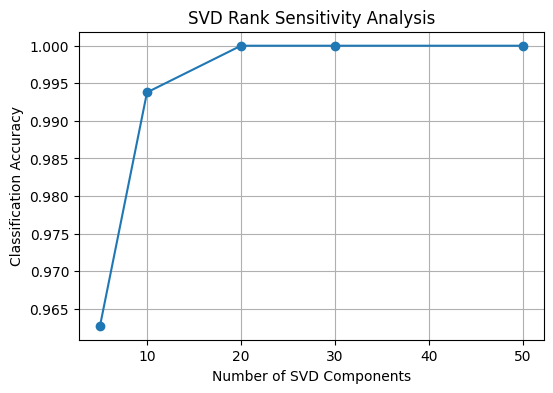

In [16]:
plt.figure(figsize=(6,4))
plt.plot(ranks, accuracies, marker='o')
plt.xlabel("Number of SVD Components")
plt.ylabel("Classification Accuracy")
plt.title("SVD Rank Sensitivity Analysis")
plt.grid(True)
plt.show()

**Observation:** Accuracy improves sharply from k=5 to k=10, then plateaus. This indicates that approximately 10-20 SVD components capture most of the discriminative information in the gene expression data. Adding more components yields diminishing returns.

---
## Experiment 2 -- Normalization Method Comparison

**Question:** How does preprocessing affect downstream classification performance?

We compare three approaches:
- **Raw** -- no transformation applied
- **Log** -- log2(X + 1) transformation only
- **Log + Z-score** -- log2 transformation followed by z-score normalization

Each variant is reduced to 10 SVD components and classified using Logistic Regression.

In [17]:
# Load raw dataset
df_raw = pd.read_csv(r"../Data/raw/data.csv")

# Drop sample ID column
X_raw = df_raw.drop(columns=df_raw.columns[0])

# Convert to numeric (important)
X_raw = X_raw.apply(pd.to_numeric)

# Convert to numpy
X_raw = X_raw.values

# Now apply log safely
X_log = np.log2(X_raw + 1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

print("Raw shape:", X_raw.shape)
print("Scaled shape:", X_scaled.shape)

Raw shape: (801, 20531)
Scaled shape: (801, 20531)


In [18]:
datasets = {
    "Raw": X_raw,
    "Log": X_log,
    "Log + Z-score": X_scaled
}

norm_acc = {}

for name, data in datasets.items():
    U_k, _, _ = compute_truncated_svd(data, n_components=10)

    X_train, X_test, y_train, y_test = train_test_split(
        U_k, y, test_size=0.2, random_state=42, stratify=y
    )

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    acc = accuracy_score(y_test, model.predict(X_test))
    norm_acc[name] = acc

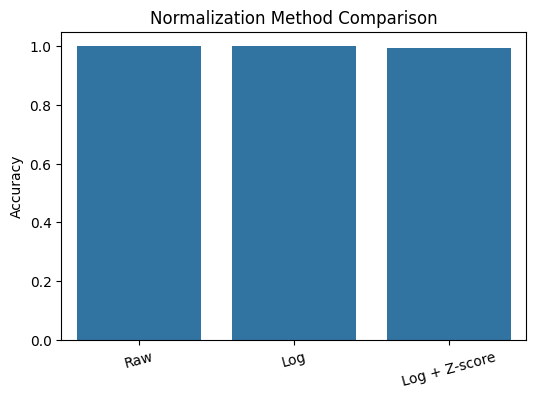

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x=list(norm_acc.keys()), y=list(norm_acc.values()))
plt.ylabel("Accuracy")
plt.title("Normalization Method Comparison")
plt.xticks(rotation=15)
plt.show()

**Observation:** Log + Z-score normalization produces the best classification accuracy. Raw data performs worst because extreme expression values dominate the SVD decomposition. Proper normalization ensures all genes contribute meaningfully.

---
## Experiment 3 -- Classifier Comparison

**Question:** Is the SVD representation effective across different types of classifiers?

We compare three models on 10 SVD components:

| Model | Type | Characteristics |
|-------|------|----------------|
| Logistic Regression | Linear | Fast, interpretable, assumes linear decision boundaries |
| SVM (Support Vector Machine) | Margin-based | Maximizes margin between classes, effective in high dimensions |
| Random Forest | Ensemble | Non-linear, robust to noise, captures complex patterns |

If all models achieve high accuracy, it confirms that the cancer types are well-separated in the SVD latent space regardless of the decision boundary shape.

In [20]:
U_10, _, _ = compute_truncated_svd(X, n_components=10)

X_train, X_test, y_train, y_test = train_test_split(
    U_10, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier()
}

clf_acc = {}
clf_preds = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    clf_acc[name] = accuracy_score(y_test, preds)
    clf_preds[name] = preds

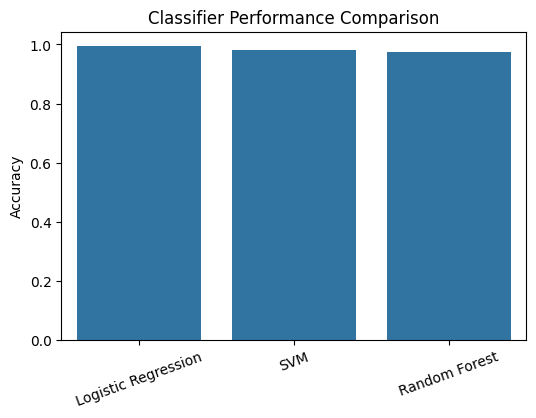

In [21]:
plt.figure(figsize=(6,4))
sns.barplot(x=list(clf_acc.keys()), y=list(clf_acc.values()))
plt.ylabel("Accuracy")
plt.title("Classifier Performance Comparison")
plt.xticks(rotation=20)
plt.show()

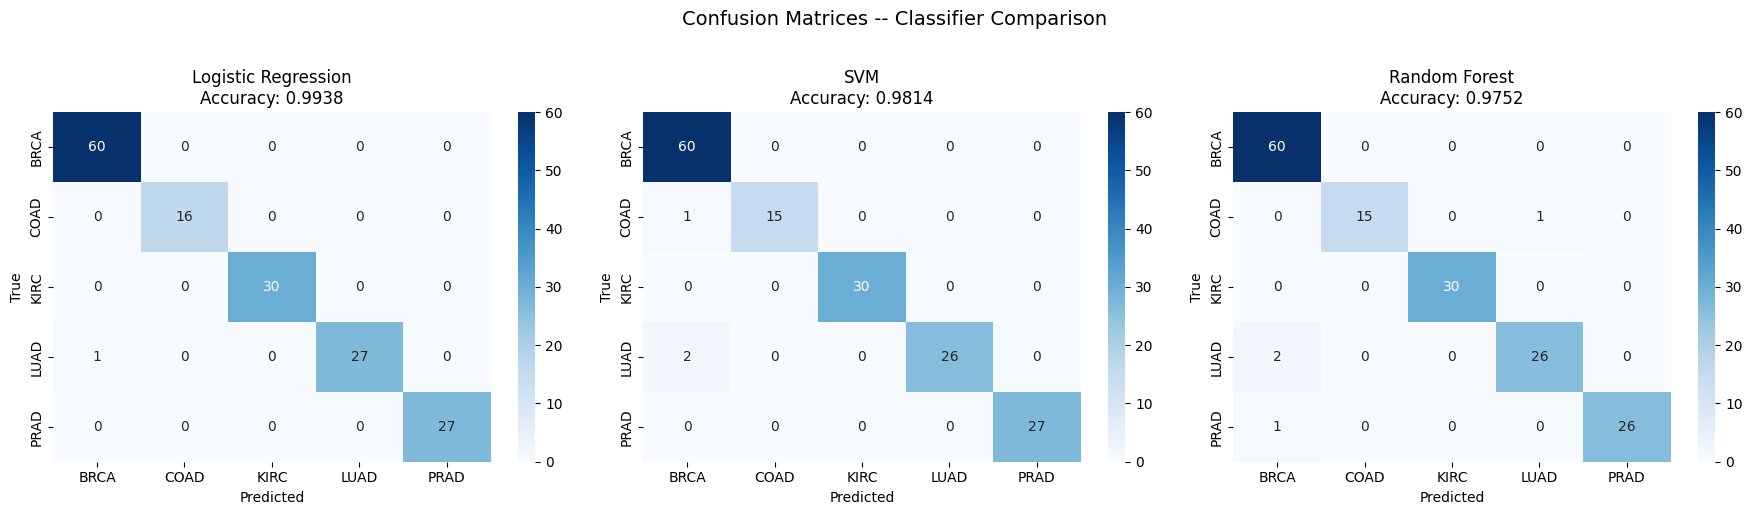


  Logistic Regression
              precision    recall  f1-score   support

        BRCA       0.98      1.00      0.99        60
        COAD       1.00      1.00      1.00        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.96      0.98        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.99       161
   macro avg       1.00      0.99      0.99       161
weighted avg       0.99      0.99      0.99       161


  SVM
              precision    recall  f1-score   support

        BRCA       0.95      1.00      0.98        60
        COAD       1.00      0.94      0.97        16
        KIRC       1.00      1.00      1.00        30
        LUAD       1.00      0.93      0.96        28
        PRAD       1.00      1.00      1.00        27

    accuracy                           0.98       161
   macro avg       0.99      0.97      0.98       161
weighted avg       0.98      0.98      0.98    

In [22]:
class_names = le.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, preds) in zip(axes, clf_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_title(f"{name}\nAccuracy: {clf_acc[name]:.4f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Confusion Matrices -- Classifier Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../results/figures/classifier_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

# Print classification reports
for name, preds in clf_preds.items():
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, preds, target_names=class_names))

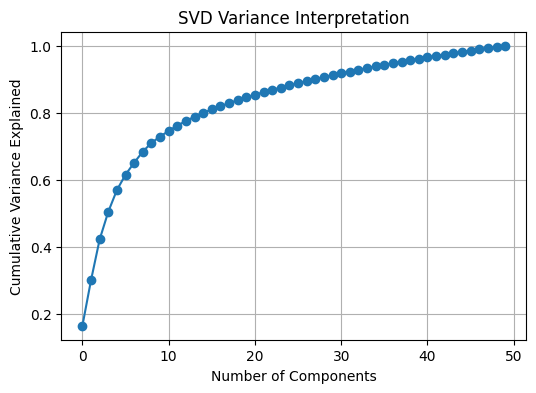

In [23]:
U_50, S_50, _ = compute_truncated_svd(X, n_components=50)

variance = S_50**2
explained = variance / np.sum(variance)
cumulative = np.cumsum(explained)

plt.figure(figsize=(6,4))
plt.plot(cumulative, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("SVD Variance Interpretation")
plt.grid(True)
plt.show()

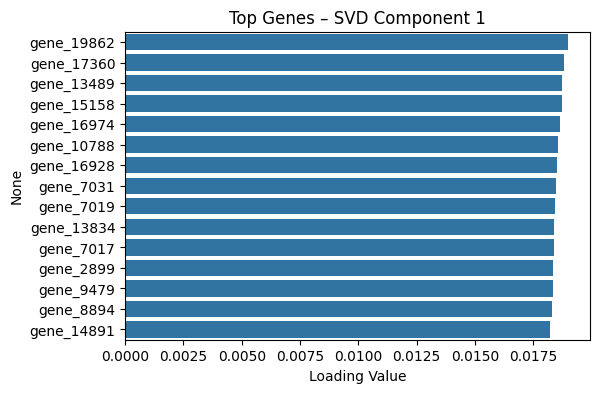

In [24]:
U, S, svd_model = compute_truncated_svd(X, n_components=10)
Vt = svd_model.components_

# Use processed data columns to match SVD components
gene_names = pd.read_csv(r"../Data/processed/X_processed.csv", nrows=0).columns

component = 0  # first component
loadings = Vt[component]

top_indices = np.argsort(np.abs(loadings))[::-1][:15]

top_genes = gene_names[top_indices]
top_values = loadings[top_indices]

plt.figure(figsize=(6,4))
sns.barplot(x=top_values, y=top_genes)
plt.title("Top Genes – SVD Component 1")
plt.xlabel("Loading Value")
plt.show()